In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("train.csv")
print(df.shape)

(1460, 81)


In [4]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1. Analysis missing Values

In [6]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values>0]
missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

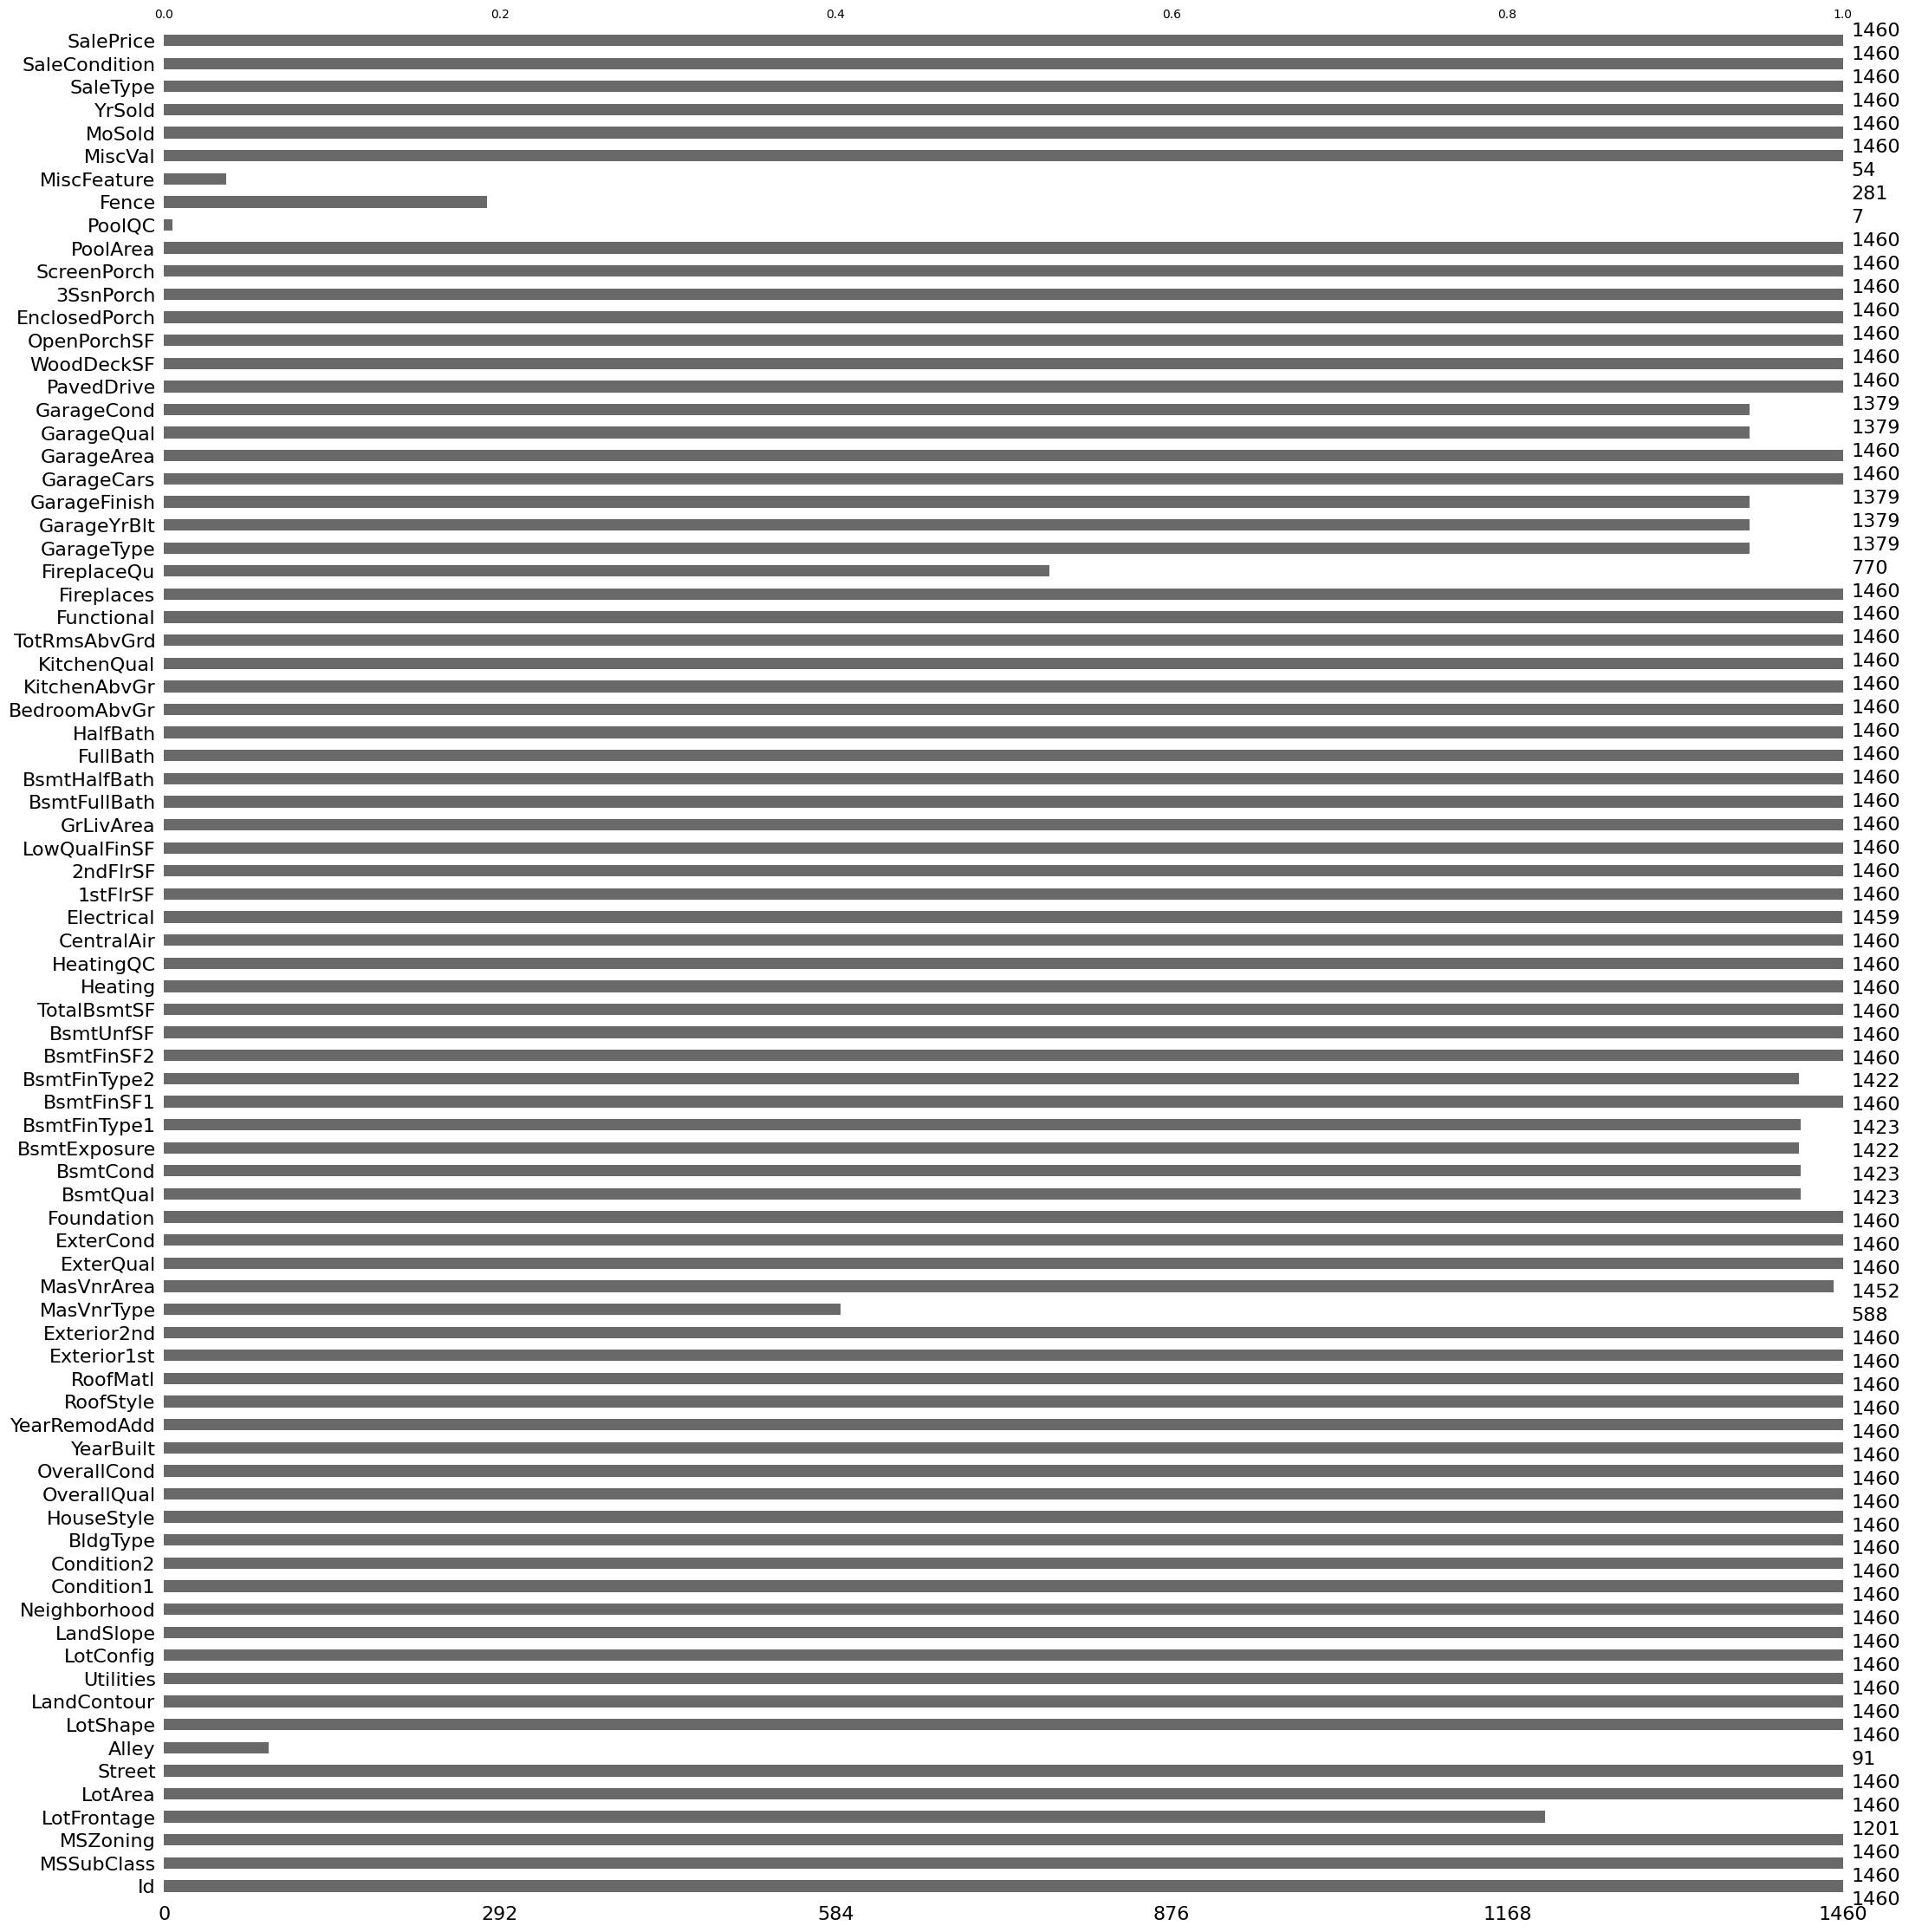

In [7]:
# Shows How much data missing column-wise
import missingno as msno
plt.figure(figsize=(12,8))
msno.bar(df)
plt.show()

# long-bar or completed bar => complete data
# short-bar => incomplete data

<Figure size 1200x800 with 0 Axes>

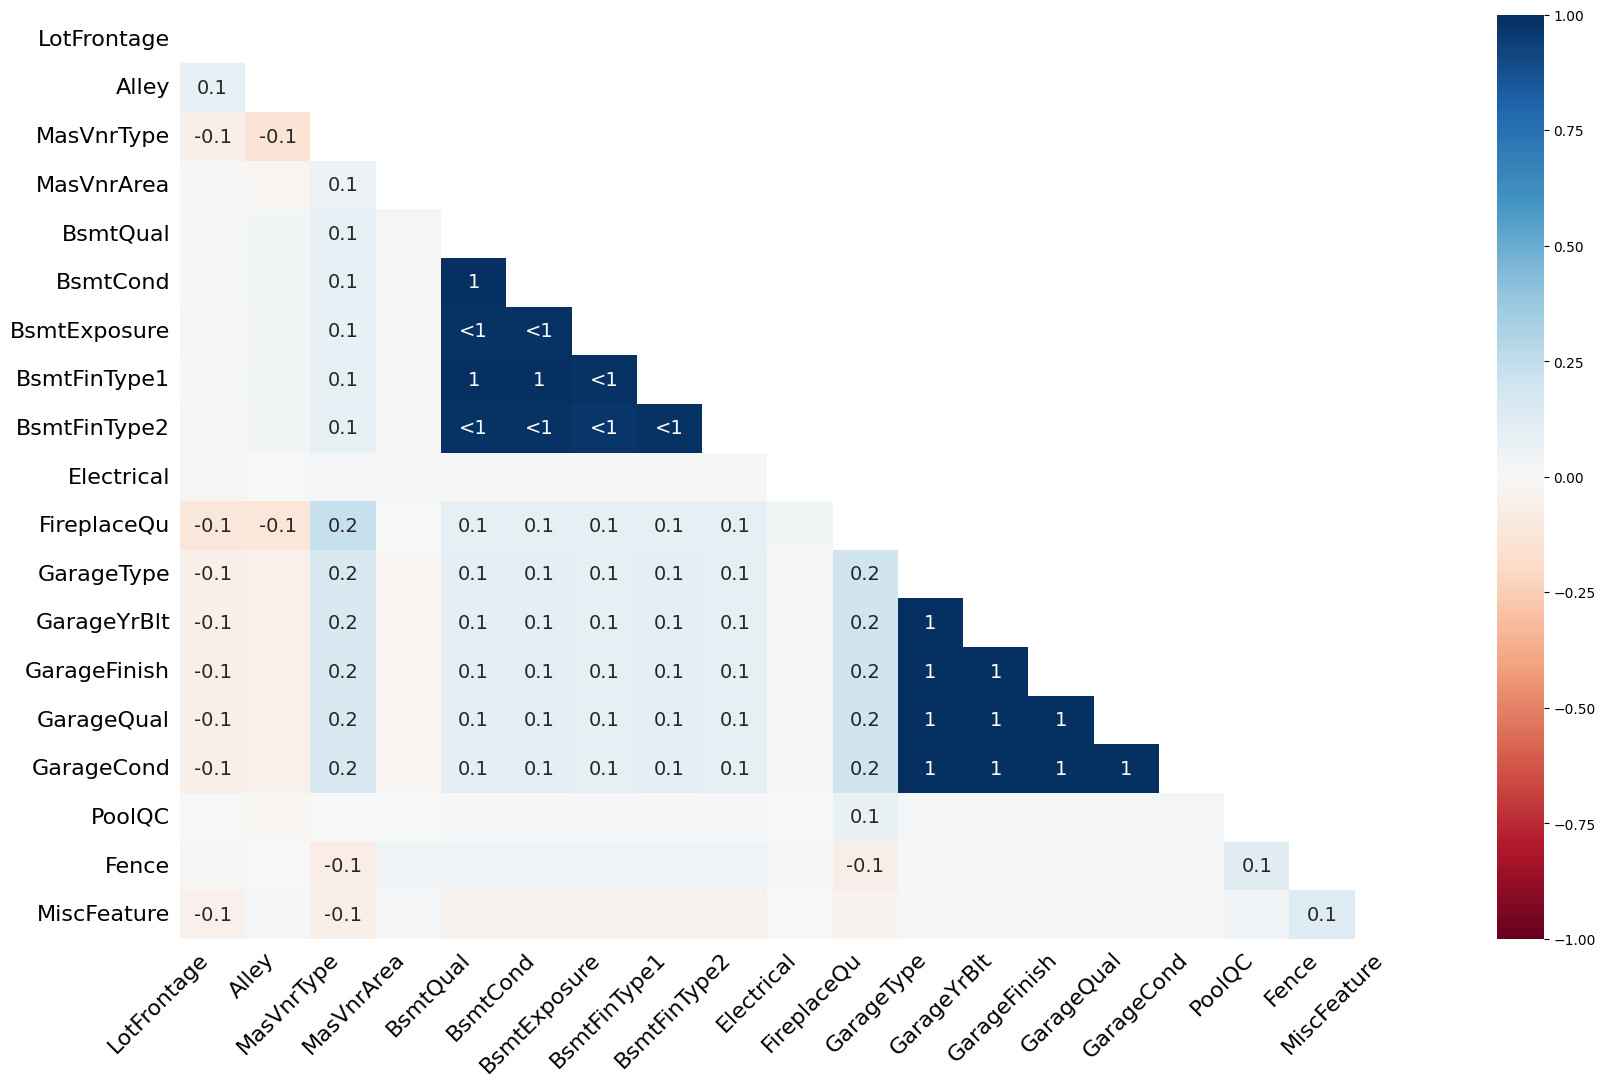

'\nvalue = 1 -> both columns tends to bemissing together\nvalue = 0 -> no relation\nvalue = -ve -> if one is missing , second is probably present \n'

In [8]:
plt.figure(figsize=(12,8))
msno.heatmap(df)
plt.show()
"""
value = 1 -> both columns tends to bemissing together
value = 0 -> no relation
value = -ve -> if one is missing , second is probably present 
"""

## 2. Deletion Methods

In [9]:
df_listwise=df.dropna()
print(f"Original Data Rows: {df.shape[0]}")
print(f"After Deleting NaN, Rows: {df_listwise.shape[0]}")

Original Data Rows: 1460
After Deleting NaN, Rows: 0


## 3. Imputation

### 3.1 Simple Imputation

#### 3.1.A Mean Imputation
- Uses ->
    * can only be used for Numerical Data

- Issue -> 
    * it'll put whole distribution towards mean
    * underestimated spread (variance)

In [10]:
# 1)Mean Imputation -> only Applicable for numerical data

df_mean_imputed = df.copy()
LotFrontage_mean = df_mean_imputed["LotFrontage"].mean()
# df_mean_imputed["LotFrontage"].fillna(LotFrontage_mean , inplace=True)
df_mean_imputed.fillna({"LotFrontage": LotFrontage_mean}, inplace=True)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


#### 3.1.B Median Imputation
- Uses ->
    * Can only be used for Numerical Data


In [11]:
df_median_imputed = df.copy()
LotFrontage_median = df_median_imputed["LotFrontage"].median()
df_median_imputed.fillna({"LotFrontage" : LotFrontage_median} , inplace=True)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


#### 3.1.C Mode Imputation

In [12]:
df_mode_imputed = df.copy()
LotFrontage_mode = df_mode_imputed["LotFrontage"].mode()
df_mode_imputed.fillna({"LotFrontage":LotFrontage_mode} , inplace=True)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


#### 3.1.D KNN Imputation

In [13]:
from sklearn.impute import KNNImputer
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_imputed = df.copy()
numerical_columns = df_knn_imputed.select_dtypes(include=(np.number)).columns
df_knn_imputed[numerical_columns] = knn_imputer.fit_transform(df_knn_imputed[numerical_columns])

### 4. Visualization

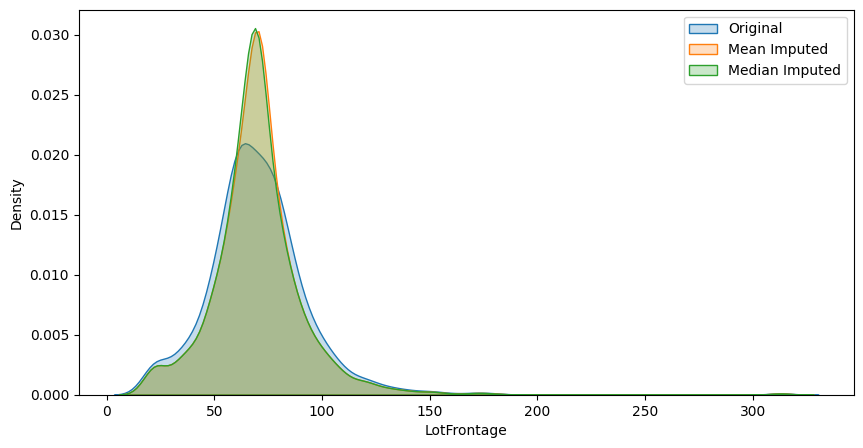

In [14]:
plt.figure(figsize=(10,5))
sns.kdeplot(df["LotFrontage"] , label="Original" , fill=True)
sns.kdeplot(df_mean_imputed["LotFrontage"] , label="Mean Imputed" , fill=True)
sns.kdeplot(df_median_imputed["LotFrontage"] , label="Median Imputed" , fill=True)
# sns.kdeplot(df_mode_imputed["LotFrontage"] , label="Mode Imputed" , fill=True)
plt.legend()

### 5. Feature Scaling

In [15]:
def summary_stats(series):
    return {
        "mean":series.mean(),
        "std":series.std(),
        "skewness":series.skew()
    }

def compare_distribution(original , transformed , title):
    fig , axes = plt.subplots(1,2,figsize=(12,4))
    sns.histplot(original , bins=30 , kde=True , ax=axes[0])
    axes[0].set_title(f"{title} - Before")
    sns.histplot(transformed , bins=30 , kde=True , ax=axes[1])
    axes[1].set_title(f'{title} - After')
    plt.show()

#### 5.1 Standard Scaling
### **Standard Scaling (Z-Score Normalization)**

Standard scaling ek technique hai jisse data features ko ek standard scale par laya jata hai. Iske baad data ka **Mean ($\mu$) 0** aur **Standard Deviation ($\sigma$) 1** ho jata hai.

#### **Formula:**
$$ z = \frac{x - \mu}{\sigma} $$

**Range:** Standard Scaling ka koi fixed min-max range nahi hota hai (jaise 0 se 1). Iski values theoretically $-\infty$ (negative infinity) se $+\infty$ (positive infinity) tak ja sakti hain. Lekin practically, zyada tar data (lagbhag 99.7%) **-3 se +3** ke beech mein hi aata hai.

**Jahan:**
* $z$ = Scaled value (Naya data point)
* $x$ = Original data point
* $\mu$ (Mu) = Feature ka Mean (औसत)
* $\sigma$ (Sigma) = Feature ka Standard Deviation (मानक विचलन)

**Kyun Use Karte Hain?**
Kyunki Machine Learning models (jaise KNN, SVM) distance par kaam karte hain. Agar features alag-alag scale par hon (jaise ek 1-10 aur dusra 1000-5000), toh model sahi se train nahi ho pata.

In [16]:
from sklearn.preprocessing import StandardScaler
col = "LotFrontage"
standard_scaler = StandardScaler()
scaled_ = standard_scaler.fit_transform(df[[col]])
scaled_.flatten()

array([-0.20803433,  0.40989452, -0.08444856, ..., -0.16683907,
       -0.08444856,  0.20391824], shape=(1460,))

In [17]:
print(f"Before: {summary_stats(df[col].dropna())}")
print(f"After: {summary_stats(pd.Series(scaled_.flatten()))}")

Before: {'mean': np.float64(70.04995836802665), 'std': np.float64(24.284751774483208), 'skewness': np.float64(2.1635691423248837)}
After: {'mean': np.float64(-2.677107310003708e-16), 'std': np.float64(1.0004165798972613), 'skewness': np.float64(2.1635691423248846)}


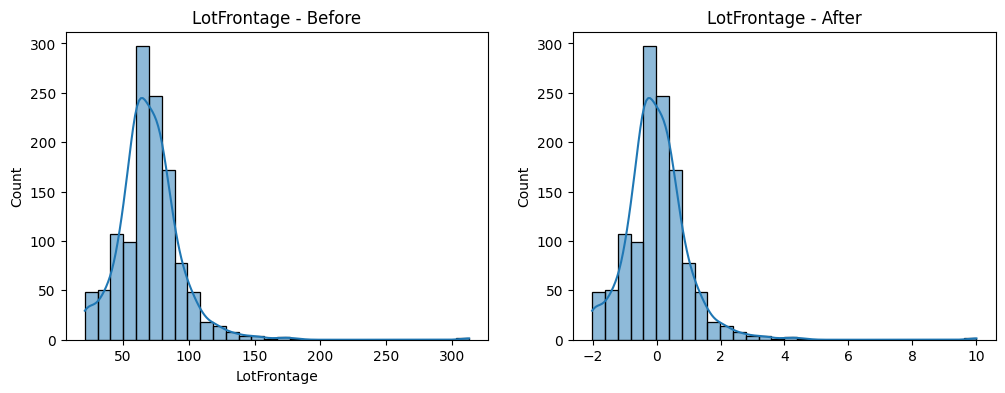

In [18]:
compare_distribution(df[col].dropna() , scaled_.flatten() , col)

#### 5.2 MinMax Scaling
### **Min-Max Scaling (Normalization)**

Min-Max Scaling ek aisi technique hai jo data ki values ko shrink karke ek fixed range mein le aati hai, by default yeh range **0 se 1** ke beech hoti hai. 

#### **Formula:**
$$ x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}} $$

**Jahan:**
* $x_{scaled}$ = Scaled value (Naya data point jo 0 aur 1 ke beech hoga)
* $x$ = Original data point
* $x_{min}$ = Us feature (column) ki sabse choti (minimum) value
* $x_{max}$ = Us feature (column) ki sabse badi (maximum) value

#### **:** 
Min-Max Scaling ki range bilkul fixed hoti hai. Iski values hamesha **0 se 1** ke beech hi aati hain. (Zaroorat padne par aap is custom range ko -1 se 1 tak bhi change kar sakte hain).

**Kyun Use Karte Hain?**
Yeh tab bahut kaam aata hai jab aapko data ek strict boundary ke andar chahiye hota hai (jaise Deep Learning mein Image pixels ko 0-255 se 0-1 range mein convert karna), ya phir jab aapka data Normal (Gaussian) distribution follow nahi karta.

In [19]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
col = "LotFrontage"
scaled_ = min_max_scaler.fit_transform(df[[col]])

In [20]:
print(f"Before : {summary_stats(df[col].dropna())}")
print(f"After : {summary_stats(pd.Series(scaled_.flatten()))}")

Before : {'mean': np.float64(70.04995836802665), 'std': np.float64(24.284751774483208), 'skewness': np.float64(2.1635691423248837)}
After : {'mean': np.float64(0.1679793094795433), 'std': np.float64(0.0831669581317918), 'skewness': np.float64(2.1635691423248846)}


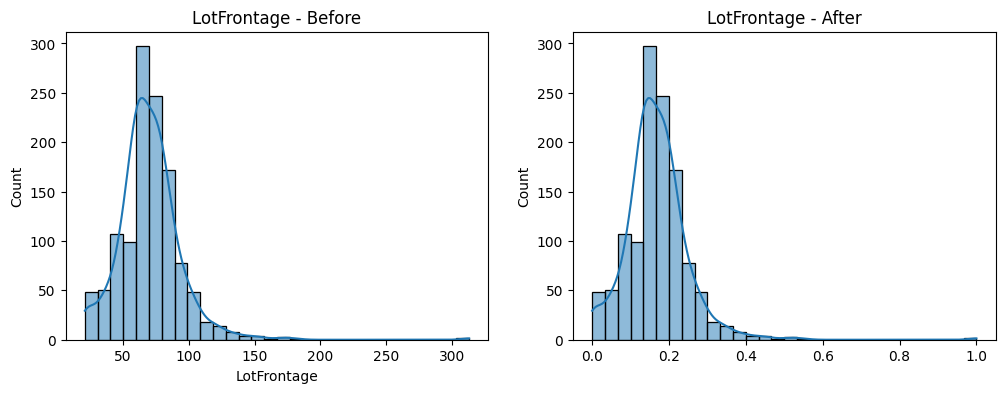

In [21]:
compare_distribution(df[col].dropna() , scaled_.flatten() , col)

#### 5.3 RobustScaler
### **Robust Scaling (RobustScaler)**

Robust Scaling ek aisi technique hai jo data mein majood **Outliers** (bahut ajeeb ya extreme values, jaise achanak se koi bahut bada number) se deal karne ke liye banayi gayi hai. 

Standard Scaler *Mean* aur *Standard Deviation* ka use karta hai, jo outliers se bahut jaldi kharab (affect) ho jate hain. Isliye, RobustScaler unki jagah **Median** (madhyika) aur **IQR (Interquartile Range)** ka use karta hai.

#### **Formula:**
$$ x_{scaled} = \frac{x - \text{Median}}{IQR} $$
*(Yahan $IQR = Q_3 - Q_1$ yani 75th Percentile - 25th Percentile)*

**Jahan:**
* $x_{scaled}$ = Scaled value (Naya data point)
* $x$ = Original data point
* $\text{Median} (Q_2)$ = Data ki middle value (50th percentile)
* $IQR$ = Interquartile Range (yeh data ke middle 50% hisse ka spread batata hai)

#### **Range:** 
Standard Scaler ki tarah hi, RobustScaler ka bhi koi fixed min-max range nahi hota. Lekin iska fayda yeh hai ki yeh outliers ke asar ko daba deta hai, jisse aapka main data achhe se scale ho jata hai.

**Kyun Use Karte Hain?**
Jab aapke dataset mein **bahut saare Outliers** hon. Kyunki outliers Mean aur Max values ko puri tarah hila dete hain, isliye wahan Min-Max ya Standard Scaler theek se kaam nahi karte. Aisi situation mein RobustScaler sabse best choice hoti hai!

In [22]:
from sklearn.preprocessing import RobustScaler

col = "LotFrontage"
robust_scaler = RobustScaler()
scaled_ = robust_scaler.fit_transform(df[[col]])


In [23]:
print(f"Before : {summary_stats(df[col].dropna())}")
print(f"After : {pd.Series(scaled_.flatten())}")

Before : {'mean': np.float64(70.04995836802665), 'std': np.float64(24.284751774483208), 'skewness': np.float64(2.1635691423248837)}
After : 0      -0.190476
1       0.523810
2      -0.047619
3      -0.428571
4       0.714286
          ...   
1455   -0.333333
1456    0.761905
1457   -0.142857
1458   -0.047619
1459    0.285714
Length: 1460, dtype: float64


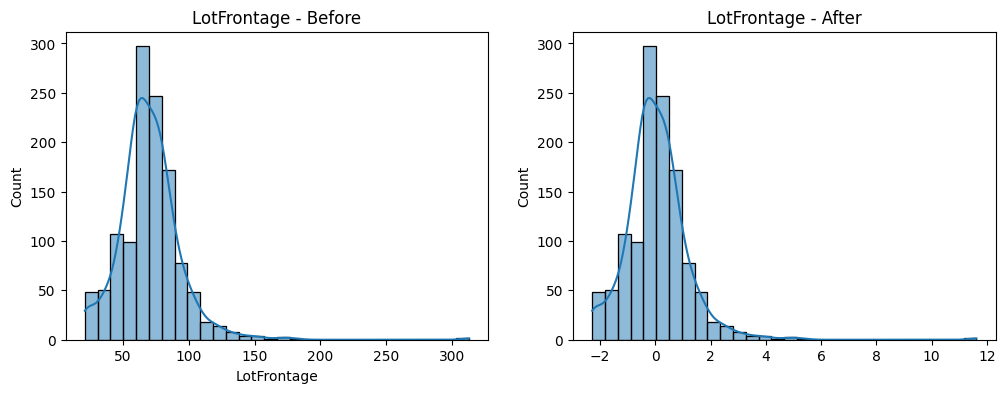

In [24]:
compare_distribution(df[col].dropna() , scaled_.flatten() , col)

#### 5.4 Log Transformation

### **Log Scaling (Log Transformation)**

Log Scaling (ya Log Transformation) ek non-linear scaling technique hai. Iska use tab kiya jata hai jab aapka data **highly skewed** (ek hi taraf bahut zyada jhuka hua) ho. Yeh bade numbers ko compress (shrink) karke chhote numbers ke kareeb le aata hai, jisse data Normal Distribution (bell curve) jaisa ban jata hai.

#### **Formula:**
$$ x_{scaled} = \log(x) $$

*(Zaroori Note: Log(0) undefined hota hai. Isliye agar aapke data mein 0 aa sakta hai, toh error se bachne ke liye hum **$\log(x + 1)$** ka use karte hain, jise Numpy mein `np.log1p` kehte hain).*

**Jahan:**
* $x_{scaled}$ = Naya scaled data point
* $x$ = Original data point
* $\log$ = Natural logarithm (ya base-10 log)

#### **Range:** 
Iska koi fixed 0-1 range nahi hota. Yeh original values par depend karta hai. Lekin iska asar samajhne ke liye yeh dekhein: (Agar Base-10 log lein) toh 10 ban jata hai 1, 100 ban jata hai 2, aur 1000 ban jata hai 3. Yaani difference kitna jaldi shrink ho gaya!

**Kyun Use Karte Hain?**
Jab aapke paas aisa data ho jisme values bahut tezi se badh rahi hon (jaise House Prices, Logo ki Salaries, ya Website Traffic). Ek aadmi ki salary 10,000 ho sakti hai aur dusre ki 10,00,000. Itne bade difference ko model mein dalne se pehle Log Scaling karke normalize kiya jata hai taaki bada number model ko galat influence na kare.

In [25]:
col = "LotFrontage"
log_transf = np.log1p(df[col].dropna())

In [26]:
print(f"Before : {summary_stats(df[col].dropna())}")
print(f"After : {summary_stats(log_transf)}")

Before : {'mean': np.float64(70.04995836802665), 'std': np.float64(24.284751774483208), 'skewness': np.float64(2.1635691423248837)}
After : {'mean': np.float64(4.207108941714102), 'std': np.float64(0.3462283309333295), 'skewness': np.float64(-0.7287278423055492)}


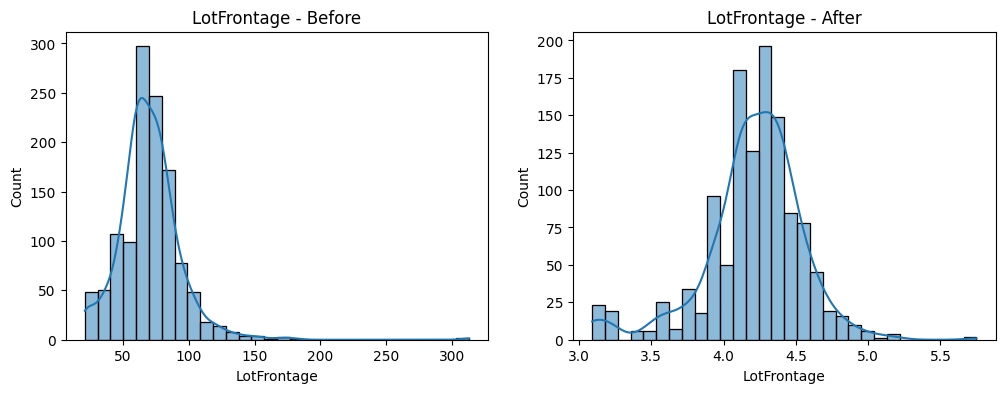

In [27]:
compare_distribution(df[col].dropna() , log_transf , col)

#### 5.5 yeo-jhonson

### **Yeo-Johnson Transformation (Power Transformer)**

Yeo-Johnson ek **Power Transformation** technique hai, jiska main kaam data ko **Normal Distribution (Gaussian/Bell Curve)** jaisa banana hota hai. 

Aapne Box-Cox transformation ka naam suna hoga, par uski sabse badi dikkat yeh hai ki woh sirf positive numbers ($x > 0$) par kaam karta hai. Wahin, **Yeo-Johnson sab par kaam karta hai** — chahe value positive ho, negative ho, ya zero ho!

#### **Formula:**
Yeo-Johnson ka formula thoda complex hai kyunki yeh data ki value (positive/negative) aur ek parameter **$\lambda$ (Lambda)** par depend karta hai:

$$
x_{scaled} = 
\begin{cases} 
\frac{(x + 1)^\lambda - 1}{\lambda} & \text{if } x \ge 0 \text{ and } \lambda \neq 0 \\
\log(x + 1) & \text{if } x \ge 0 \text{ and } \lambda = 0 \\
-\frac{(-x + 1)^{2 - \lambda} - 1}{2 - \lambda} & \text{if } x < 0 \text{ and } \lambda \neq 2 \\
-\log(-x + 1) & \text{if } x < 0 \text{ and } \lambda = 2 
\end{cases}
$$

**Jahan:**
* $x_{scaled}$ = Transform hone ke baad ka naya data.
* $x$ = Original data point.
* $\lambda$ (Lambda) = Yeh ek parameter hai jise model khud dhundhta hai (Maximum Likelihood Estimation se) taaki data sabse best tarike se Normal distribution ban sake.



#### **Range:** 
Iska koi fixed range (jaise 0-1) nahi hota. Iska main focus range fix karna nahi, balki data ka shape (distribution) theek karke use Gaussian curve jaisa banana hota hai.

**Kyun Use Karte Hain?**
Jab aapke paas highly skewed data ho aur usme **0 ya negative values** bhi majood hon. Bahut se Machine Learning models (jaise Linear Regression, Logistic Regression, ya Neural Networks) tab sabse best perform karte hain jab data Normal distribution (Bell curve) ko follow karta ho. Yeo-Johnson aapke tedhe-medhe data ko us bell curve mein fit karne ka kaam karta hai.

In [28]:
from sklearn.preprocessing import PowerTransformer

col = "LotFrontage"
power_transf = PowerTransformer(method="yeo-johnson")
scaled_ = power_transf.fit_transform(df[[col]])

In [29]:
print(f"Before : {summary_stats(df[col])}")
print(f"After : {summary_stats(pd.Series(scaled_.flatten()))}")


Before : {'mean': np.float64(70.04995836802665), 'std': np.float64(24.284751774483208), 'skewness': np.float64(2.163569142324884)}
After : {'mean': np.float64(-7.3805334126621565e-16), 'std': np.float64(1.0004165798972613), 'skewness': np.float64(0.11527708161436032)}


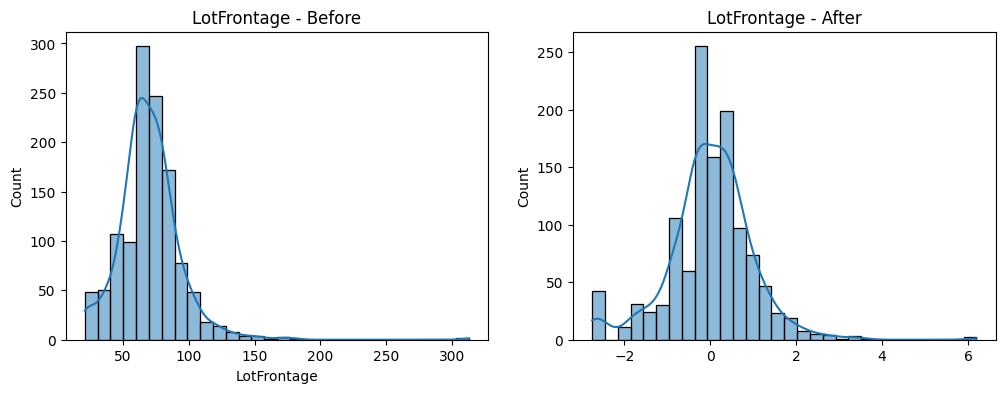

In [30]:
compare_distribution(df[col].dropna() , scaled_.flatten() , col)

### 6. Data Encoding

In [31]:
df.columns.sort_values()

Index(['1stFlrSF', '2ndFlrSF', '3SsnPorch', 'Alley', 'BedroomAbvGr',
       'BldgType', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtFinType1', 'BsmtFinType2', 'BsmtFullBath', 'BsmtHalfBath',
       'BsmtQual', 'BsmtUnfSF', 'CentralAir', 'Condition1', 'Condition2',
       'Electrical', 'EnclosedPorch', 'ExterCond', 'ExterQual', 'Exterior1st',
       'Exterior2nd', 'Fence', 'FireplaceQu', 'Fireplaces', 'Foundation',
       'FullBath', 'Functional', 'GarageArea', 'GarageCars', 'GarageCond',
       'GarageFinish', 'GarageQual', 'GarageType', 'GarageYrBlt', 'GrLivArea',
       'HalfBath', 'Heating', 'HeatingQC', 'HouseStyle', 'Id', 'KitchenAbvGr',
       'KitchenQual', 'LandContour', 'LandSlope', 'LotArea', 'LotConfig',
       'LotFrontage', 'LotShape', 'LowQualFinSF', 'MSSubClass', 'MSZoning',
       'MasVnrArea', 'MasVnrType', 'MiscFeature', 'MiscVal', 'MoSold',
       'Neighborhood', 'OpenPorchSF', 'OverallCond', 'OverallQual',
       'PavedDrive', 'PoolArea', 'Po

#### 6.1.a Label Encoding : Not Ordered Encoding

In [32]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

col = "MSZoning"
print(f"Before : {df[col].unique()}")

# Method-1 : Using Pandas
df["MSZoning_label_pd"] = pd.factorize(df[col])[0]

# Method-2 : Using sklearn
le = LabelEncoder()
df["MSZoning_label_sklearn"] = le.fit_transform(df[col])

print(f"After Pandas Factorize : {df['MSZoning_label_pd'].unique()}")
print(f"After sklearn Factorize : {df['MSZoning_label_sklearn'].unique()}")

Before : <StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str
After Pandas Factorize : [0 1 2 3 4]
After sklearn Factorize : [3 4 0 1 2]


#### 6.1.b Label Encoding : Ordinal Encoding

In [33]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_order = [[ 'C (all)' ,'RM' , 'RH' , 'RL' , 'FV' ]]

oe = OrdinalEncoder(categories=ordinal_order)
df["MSZoning_ordinal"] = oe.fit_transform(df[[col]])

print(f"Before : {df[col].unique()}")
print()

Before : <StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str



#### 6.2 OneHotEncoding

In [34]:
col = "MSZoning"

# By using Pandas
import pandas as pd
MSZoning_ohe_pd = pd.get_dummies(df[col] , prefix="MSZoning")

# By using sklearn
from sklearn.preprocessing import OneHotEncoder
ohe_skln = OneHotEncoder(sparse_output=False , drop=None)
MSZoning_ohe_skln=ohe_skln.fit_transform(df[[col]])

ohe_skln_df = pd.DataFrame(MSZoning_ohe_skln , columns=ohe_skln.get_feature_names_out([col]))

skln_ohe = pd.concat([df[col] , ohe_skln_df] , axis=1)
skln_ohe

,MSZoning,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM
0,RL,0.0,0.0,0.0,1.0,0.0
1,RL,0.0,0.0,0.0,1.0,0.0
2,RL,0.0,0.0,0.0,1.0,0.0
3,RL,0.0,0.0,0.0,1.0,0.0
4,RL,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...
1455,RL,0.0,0.0,0.0,1.0,0.0
1456,RL,0.0,0.0,0.0,1.0,0.0
1457,RL,0.0,0.0,0.0,1.0,0.0
1458,RL,0.0,0.0,0.0,1.0,0.0


#### 6.3 Target Encoding

In [35]:
!pip install category_encoders

In [36]:
import category_encoders as ce

col = "Neighborhood"
print("Before:", df[col].unique())

target_enc = ce.TargetEncoder(cols=[col])
df["Neighborhood_target"] = target_enc.fit_transform(df[col], df["SalePrice"])
unique_neighborhood_target = df[[col, "Neighborhood_target"]].drop_duplicates().reset_index(drop=True)
print("\n --- Unique Neighborhood values and their Target Encoded values --- ")
print(unique_neighborhood_target)


Before: <StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str

 --- Unique Neighborhood values and their Target Encoded values --- 
   Neighborhood  Neighborhood_target
0       CollgCr        197965.734807
1       Veenker        197643.209810
2       Crawfor        209344.287867
3       NoRidge        318453.591177
4       Mitchel        157555.763763
5       Somerst        225319.439258
6        NWAmes        189009.693995
7       OldTown        128230.118126
8       BrkSide        126061.309722
9        Sawyer        136991.546950
10      NridgHt        315819.259117
11        NAmes        145847.080044
12      SawyerW        186444.004409
13       IDOTRR        112604.177463
14      MeadowV        145878.781837
15      Edward

#### 6.4 Frequency Encoding

In [37]:
col = "Neighborhood"
print("Before:", df[col].unique()[:5])

# Method Pandas : map
freq_encoding = df[col].value_counts().to_dict()
df["Neighborhood_freq"] = df[col].map(freq_encoding)

# Method category_encoders
count_enc = ce.CountEncoder(cols=[col])
df["Neighborhood_freq_ce"] = count_enc.fit_transform(df[col])

unique_neighborhood_frequency_encoding = df[[col, "Neighborhood_freq_ce"]].drop_duplicates().reset_index(drop=True)

print("\n --- Unique Neighborhood values and their frequence Encoded values --- ")
print(unique_neighborhood_frequency_encoding)

Before: <StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel']
Length: 5, dtype: str

 --- Unique Neighborhood values and their frequence Encoded values --- 
   Neighborhood  Neighborhood_freq_ce
0       CollgCr                   150
1       Veenker                    11
2       Crawfor                    51
3       NoRidge                    41
4       Mitchel                    49
5       Somerst                    86
6        NWAmes                    73
7       OldTown                   113
8       BrkSide                    58
9        Sawyer                    74
10      NridgHt                    77
11        NAmes                   225
12      SawyerW                    59
13       IDOTRR                    37
14      MeadowV                    17
15      Edwards                   100
16       Timber                    38
17      Gilbert                    79
18      StoneBr                    25
19      ClearCr                    28
20      NPkVill              

### 7 Feature Selection

In [ ]:
import statsmodels.api as sm

numeric_data = df.select_dtypes(include=["number"])
total_rows = len(numeric_data)
missing_count = numeric_data.isnull().sum()
missing_percentage = (missing_count/total_rows)*100
dropping_column = missing_percentage[missing_percentage>30].index.tolist()
cleaned_df = numeric_data.drop(columns=dropping_column)